### SK쉴더스 개발6기 홍서연
| First Assignment - 웹스크래핑 연습문제1
* 선택사항인 문제까지 모두 구현 완료하였습니다.

In [9]:
# 1-1. Daum 뉴스기사 제목 스크래핑하기
import requests
from bs4 import BeautifulSoup

url = 'https://news.daum.net/economy'
headers = {
    'User-Agent': (
        'Mozilla/5.0 (Windows NT 10.0; Win64; x64) '
        'AppleWebKit/537.36 (KHTML, like Gecko) '
        'Chrome/126.0 Safari/537.36'
    )
}

response = requests.get(url, headers=headers, timeout=10)
response.encoding = 'utf-8'

print(url)
print(type(response))
print(response.status_code)

soup = BeautifulSoup(response.text, 'html.parser')
li_tags = soup.select('ul.list_newsheadline2 li')

if not li_tags:
    li_tags = soup.select('ul.list_newsheadline li, li.item_news, div.item_news, a.link_txt')

print(type(li_tags), len(li_tags))

for li_tag in li_tags:
    if getattr(li_tag, 'name', '') == 'a':
        a_tag = li_tag
        title_tag = li_tag
    else:
        a_tag = li_tag.find('a', href=True)
        title_tag = (
            li_tag.select_one('div.cont_thumb strong.tit_txt')
            or li_tag.select_one('strong.tit_txt')
            or li_tag.select_one('.tit_txt')
            or a_tag
        )

    link = a_tag['href']
    title = title_tag.get_text(' ', strip=True)

    if title:
        print(link)
        print(title)

https://news.daum.net/economy
<class 'requests.models.Response'>
200
<class 'bs4.element.ResultSet'> 9
https://v.daum.net/v/20260813200251344
"비거주 1주택 불이익 과도"…전문가들 "실거주 특례 넓혀야"
https://v.daum.net/v/20260813191247133
방산 특화에 1,100억원 투자...1조 원 규모  'LP성장펀드' 출범
https://v.daum.net/v/20260813185245741
'모두의 창업' 1만 명 선발…비수도권에서 70% 이상 뽑는다
https://v.daum.net/v/20260813185128719
“공시가 19억~32억 주택, 2년 뒤엔 부부 공동명의 더 불리”
https://v.daum.net/v/20260813184722631
'주택신속공급'이란 명칭처럼 빠르게 착공? 태릉CC가 가늠자 [8·13 대책➀]
https://v.daum.net/v/20260813180850565
삼성생명 상반기 순익 1.9조 육박…2Q 손익은 9.1%↓
https://v.daum.net/v/20260813180729514
AI 4대 천왕 키워낸 中의 ‘인내자본’…자체칩으로 美 규제도 우회
https://v.daum.net/v/20260813180645486
전기차, 세액공제서 제외…생태계 마지노선 400만대 생산 기반 위태
https://v.daum.net/v/20260813180612472
환경평가·토지조사 동시 진행… 절차 2년7개월 더 빨라진다 [8·13 부동산 대책]


In [10]:
# 1-2. Daum 뉴스기사 제목 스크래핑하기 코드를 섹션별 함수로 구현하기
import requests
from bs4 import BeautifulSoup

section_dict = {
    '기후/환경': 'climate',
    '사회': 'society',
    '경제': 'economy',
    '정치': 'politics',
    '국제': 'world',
    '문화': 'culture',
    '생활': 'life',
    'IT/과학': 'tech',
    '인물': 'people',
}

headers = {
    'User-Agent': (
        'Mozilla/5.0 (Windows NT 10.0; Win64; x64) '
        'AppleWebKit/537.36 (KHTML, like Gecko) '
        'Chrome/126.0 Safari/537.36'
    )
}


def print_news(section_name):
    if section_name not in section_dict:
        print(f'지원하지 않는 섹션입니다: {section_name}')
        print('사용 가능한 섹션:', ', '.join(section_dict.keys()))
        return

    section = section_dict[section_name]
    url = f'https://news.daum.net/{section}'
    response = requests.get(url, headers=headers, timeout=10)
    response.encoding = 'utf-8'

    print(f'======> {url} {section_name} 뉴스 <======')

    soup = BeautifulSoup(response.text, 'html.parser')
    li_tags = soup.select('ul.list_newsheadline2 li')

    if not li_tags:
        li_tags = soup.select('ul.list_newsheadline li, li.item_news, div.item_news, a.link_txt')

    for li_tag in li_tags:
        if getattr(li_tag, 'name', '') == 'a':
            a_tag = li_tag
            title_tag = li_tag
        else:
            a_tag = li_tag.find('a', href=True)
            title_tag = (
                li_tag.select_one('div.cont_thumb strong.tit_txt')
                or li_tag.select_one('strong.tit_txt')
                or li_tag.select_one('.tit_txt')
                or a_tag
            )

        link = a_tag['href']
        title = title_tag.get_text(' ', strip=True)

        if title:
            print(link)
            print(title)


print_news('경제')
print_news('사회')

======> https://news.daum.net/economy 경제 뉴스 <======
https://v.daum.net/v/20260813200251344
"비거주 1주택 불이익 과도"…전문가들 "실거주 특례 넓혀야"
https://v.daum.net/v/20260813191247133
방산 특화에 1,100억원 투자...1조 원 규모  'LP성장펀드' 출범
https://v.daum.net/v/20260813185245741
'모두의 창업' 1만 명 선발…비수도권에서 70% 이상 뽑는다
https://v.daum.net/v/20260813185128719
“공시가 19억~32억 주택, 2년 뒤엔 부부 공동명의 더 불리”
https://v.daum.net/v/20260813184722631
'주택신속공급'이란 명칭처럼 빠르게 착공? 태릉CC가 가늠자 [8·13 대책➀]
https://v.daum.net/v/20260813180850565
삼성생명 상반기 순익 1.9조 육박…2Q 손익은 9.1%↓
https://v.daum.net/v/20260813180729514
AI 4대 천왕 키워낸 中의 ‘인내자본’…자체칩으로 美 규제도 우회
https://v.daum.net/v/20260813180645486
전기차, 세액공제서 제외…생태계 마지노선 400만대 생산 기반 위태
https://v.daum.net/v/20260813180612472
환경평가·토지조사 동시 진행… 절차 2년7개월 더 빨라진다 [8·13 부동산 대책]
======> https://news.daum.net/society 사회 뉴스 <======
https://v.daum.net/v/20260813202523080
“광주 시내버스 환승 불편 해소·배차 확대해야”
https://v.daum.net/v/20260813202407025
“진실 하나도 밝혀지지 않아…총리가 컨트롤타워 맡아야”
https://v.daum.net/v/20260813202250997
'서·논술형' 강행? 국교위원들도 "우

In [11]:
# 2-1. Nate 뉴스기사 제목 스크래핑하기 (선택)
import requests
from bs4 import BeautifulSoup
from urllib.parse import urljoin
from IPython.display import Image, display

nate_section_dict = {
    '최신뉴스': 'n0100',
    '정치': 'n0200',
    '경제': 'n0300',
    '사회': 'n0400',
    '세계': 'n0500',
    'IT/과학': 'n0600',
}

headers = {
    'User-Agent': (
        'Mozilla/5.0 (Windows NT 10.0; Win64; x64) '
        'AppleWebKit/537.36 (KHTML, like Gecko) '
        'Chrome/126.0 Safari/537.36'
    )
}


def print_nate_news(section_name, limit=5):
    if section_name not in nate_section_dict:
        print(f'지원하지 않는 섹션입니다: {section_name}')
        print('사용 가능한 섹션:', ', '.join(nate_section_dict.keys()))
        return

    mid = nate_section_dict[section_name]
    url = f'https://news.nate.com/recent?mid={mid}'
    response = requests.get(url, headers=headers, timeout=10)
    response.encoding = response.apparent_encoding or 'utf-8'

    soup = BeautifulSoup(response.text, 'html.parser')
    candidates = soup.select('div.mduSubjectList li, div.postSubjectContent, li')

    news_items = []
    seen_links = set()

    for item in candidates:
        a_tag = item.select_one('a[href*="/view/"]') or item.find('a', href=True)
        if not a_tag:
            continue

        link = urljoin(url, a_tag['href'])
        if '/view/' not in link or link in seen_links:
            continue

        title_tag = (
            item.select_one('strong.tit')
            or item.select_one('h2.tit')
            or item.select_one('span.tit')
            or item.select_one('.tit')
            or a_tag
        )
        title = title_tag.get_text(' ', strip=True)
        if not title:
            continue

        img_tag = item.find('img')
        img_url = None
        if img_tag:
            src = img_tag.get('data-src') or img_tag.get('src')
            if src:
                img_url = urljoin(url, src.strip())

        news_items.append({'title': title, 'link': link, 'image': img_url})
        seen_links.add(link)

        if len(news_items) >= limit:
            break

    print(f'======> {url} {section_name} 뉴스 <======')

    for item in news_items:
        print('기사제목:', item['title'])
        print('기사링크:', item['link'])

        if item['image']:
            print('Image:', item['image'])
            display(Image(url=item['image'], width=160))
        else:
            print('Image: 이미지 없음')

        print()


for section_name in nate_section_dict:
    print_nate_news(section_name)

======> https://news.nate.com/recent?mid=n0100 최신뉴스 뉴스 <======
기사제목: 'LG 구세주' 박해민 동점타 → 오스틴 역전 3점포! 5회에만 8득점 빅이닝…고척돔 물들인 LG의 노란색 물결 [고척현장]
기사링크: https://news.nate.com/view/20260813n35428?mid=n0100
Image: https://thumbnews.nateimg.co.kr/news90///news.nateimg.co.kr/orgImg/sc/2026/08/13/2026081301000827000051761.jpg



기사제목: "하영 증조부, 이토 히로부미 추모"…친일사전엔 빠진 이유가
기사링크: https://news.nate.com/view/20260813n25117
Image: 이미지 없음

기사제목: 이진숙 "5·18이 성역이냐?" 판 깔자…"광주는 소요사태"
기사링크: https://news.nate.com/view/20260813n24936
Image: 이미지 없음

기사제목: "벌레 같은 안중근, 전과자 김구…'듣보잡' 유관순은" SNS 조롱 기가 막힌다
기사링크: https://news.nate.com/view/20260813n10622
Image: 이미지 없음

기사제목: "집 못 지어서 미쳤나 싶게"…李정부 '닥치고 공급'에 강남·용산은 빠져
기사링크: https://news.nate.com/view/20260813n18113
Image: 이미지 없음

======> https://news.nate.com/recent?mid=n0200 정치 뉴스 <======
기사제목: 민주당 선관위, 대리투표 의혹 전 구의원 제명 제소 의결
기사링크: https://news.nate.com/view/20260813n35281?mid=n0200
Image: https://thumbnews.nateimg.co.kr/news90///news.nateimg.co.kr/orgImg/cz/2026/08/13/cz_1786621084857_518002_0.jpg



기사제목: "하영 증조부, 이토 히로부미 추모"…친일사전엔 빠진 이유가
기사링크: https://news.nate.com/view/20260813n25117
Image: 이미지 없음

기사제목: 이진숙 "5·18이 성역이냐?" 판 깔자…"광주는 소요사태"
기사링크: https://news.nate.com/view/20260813n24936
Image: 이미지 없음

기사제목: "벌레 같은 안중근, 전과자 김구…'듣보잡' 유관순은" SNS 조롱 기가 막힌다
기사링크: https://news.nate.com/view/20260813n10622
Image: 이미지 없음

기사제목: "집 못 지어서 미쳤나 싶게"…李정부 '닥치고 공급'에 강남·용산은 빠져
기사링크: https://news.nate.com/view/20260813n18113
Image: 이미지 없음

======> https://news.nate.com/recent?mid=n0300 경제 뉴스 <======
기사제목: 청년 4억 이하 비아파트 매수 지원…신혼부부 소득 합산 안해
기사링크: https://news.nate.com/view/20260813n35290?mid=n0300
Image: https://thumbnews.nateimg.co.kr/news90///news.nateimg.co.kr/orgImg/ny/2026/08/13/1357971_1786621034.jpg



기사제목: "하영 증조부, 이토 히로부미 추모"…친일사전엔 빠진 이유가
기사링크: https://news.nate.com/view/20260813n25117
Image: 이미지 없음

기사제목: 이진숙 "5·18이 성역이냐?" 판 깔자…"광주는 소요사태"
기사링크: https://news.nate.com/view/20260813n24936
Image: 이미지 없음

기사제목: "벌레 같은 안중근, 전과자 김구…'듣보잡' 유관순은" SNS 조롱 기가 막힌다
기사링크: https://news.nate.com/view/20260813n10622
Image: 이미지 없음

기사제목: "집 못 지어서 미쳤나 싶게"…李정부 '닥치고 공급'에 강남·용산은 빠져
기사링크: https://news.nate.com/view/20260813n18113
Image: 이미지 없음

======> https://news.nate.com/recent?mid=n0400 사회 뉴스 <======
기사제목: 국교위, '학교시민교육 기본원칙안' 수정 조건 의결
기사링크: https://news.nate.com/view/20260813n35090?mid=n0400
Image: https://thumbnews.nateimg.co.kr/news90///news.nateimg.co.kr/orgImg/ch/2026/08/13/ch_1786621145715_605960_0.jpg



기사제목: "하영 증조부, 이토 히로부미 추모"…친일사전엔 빠진 이유가
기사링크: https://news.nate.com/view/20260813n25117
Image: 이미지 없음

기사제목: 이진숙 "5·18이 성역이냐?" 판 깔자…"광주는 소요사태"
기사링크: https://news.nate.com/view/20260813n24936
Image: 이미지 없음

기사제목: "벌레 같은 안중근, 전과자 김구…'듣보잡' 유관순은" SNS 조롱 기가 막힌다
기사링크: https://news.nate.com/view/20260813n10622
Image: 이미지 없음

기사제목: "집 못 지어서 미쳤나 싶게"…李정부 '닥치고 공급'에 강남·용산은 빠져
기사링크: https://news.nate.com/view/20260813n18113
Image: 이미지 없음

======> https://news.nate.com/recent?mid=n0500 세계 뉴스 <======
기사제목: '챗GPT 아버지' 올트먼이 사망했다고? 구글 오류, 이유는…
기사링크: https://news.nate.com/view/20260813n15111?mid=n0500
Image: https://thumbnews.nateimg.co.kr/news90///news.nateimg.co.kr/orgImg/do/2026/08/13/134475628.1.jpg



기사제목: "하영 증조부, 이토 히로부미 추모"…친일사전엔 빠진 이유가
기사링크: https://news.nate.com/view/20260813n25117
Image: 이미지 없음

기사제목: 이진숙 "5·18이 성역이냐?" 판 깔자…"광주는 소요사태"
기사링크: https://news.nate.com/view/20260813n24936
Image: 이미지 없음

기사제목: "벌레 같은 안중근, 전과자 김구…'듣보잡' 유관순은" SNS 조롱 기가 막힌다
기사링크: https://news.nate.com/view/20260813n10622
Image: 이미지 없음

기사제목: "집 못 지어서 미쳤나 싶게"…李정부 '닥치고 공급'에 강남·용산은 빠져
기사링크: https://news.nate.com/view/20260813n18113
Image: 이미지 없음

======> https://news.nate.com/recent?mid=n0600 IT/과학 뉴스 <======
기사제목: 삼성SDS의 AI 협업 솔루션 '브리티웍스', 정부 중앙부처 9곳에 도입
기사링크: https://news.nate.com/view/20260813n35275?mid=n0600
Image: https://thumbnews.nateimg.co.kr/news90///news.nateimg.co.kr/orgImg/ee/2026/08/13/20260813203729895592.png



기사제목: "하영 증조부, 이토 히로부미 추모"…친일사전엔 빠진 이유가
기사링크: https://news.nate.com/view/20260813n25117
Image: 이미지 없음

기사제목: 이진숙 "5·18이 성역이냐?" 판 깔자…"광주는 소요사태"
기사링크: https://news.nate.com/view/20260813n24936
Image: 이미지 없음

기사제목: "벌레 같은 안중근, 전과자 김구…'듣보잡' 유관순은" SNS 조롱 기가 막힌다
기사링크: https://news.nate.com/view/20260813n10622
Image: 이미지 없음

기사제목: "집 못 지어서 미쳤나 싶게"…李정부 '닥치고 공급'에 강남·용산은 빠져
기사링크: https://news.nate.com/view/20260813n18113
Image: 이미지 없음



img\일렉시드\341\001.jpg
img\일렉시드\341\002.jpg
img\일렉시드\341\003.jpg
img\일렉시드\341\004.jpg
img\일렉시드\341\005.jpg
img\일렉시드\341\006.jpg
img\일렉시드\341\007.jpg
img\일렉시드\341\008.jpg
img\일렉시드\341\009.jpg
img\일렉시드\341\010.jpg
img\일렉시드\341\011.jpg
img\일렉시드\341\012.jpg
img\일렉시드\341\013.jpg
img\일렉시드\341\014.jpg
img\일렉시드\341\015.jpg
img\일렉시드\341\016.jpg
img\일렉시드\341\017.jpg
img\일렉시드\341\018.jpg
img\일렉시드\341\019.jpg
img\일렉시드\341\020.jpg
img\일렉시드\341\021.jpg
img\일렉시드\341\022.jpg
img\일렉시드\341\023.jpg
img\일렉시드\341\024.jpg
img\일렉시드\341\025.jpg
img\일렉시드\341\026.jpg
img\일렉시드\341\027.jpg
img\일렉시드\341\028.jpg
img\일렉시드\341\029.jpg
img\일렉시드\341\030.jpg
img\일렉시드\341\031.jpg
img\일렉시드\341\032.jpg
img\일렉시드\341\033.jpg
img\일렉시드\341\034.jpg
img\일렉시드\341\035.jpg
img\일렉시드\341\036.jpg
img\일렉시드\341\037.jpg
img\일렉시드\341\038.jpg
img\일렉시드\341\039.jpg
img\일렉시드\341\040.jpg
img\일렉시드\341\041.jpg
img\일렉시드\341\042.jpg
img\일렉시드\341\043.jpg
img\일렉시드\341\044.jpg
img\일렉시드\341\045.jpg
img\일렉시드\341\046.jpg
img\일렉시드\341\047.jpg
img\일렉시드\341\

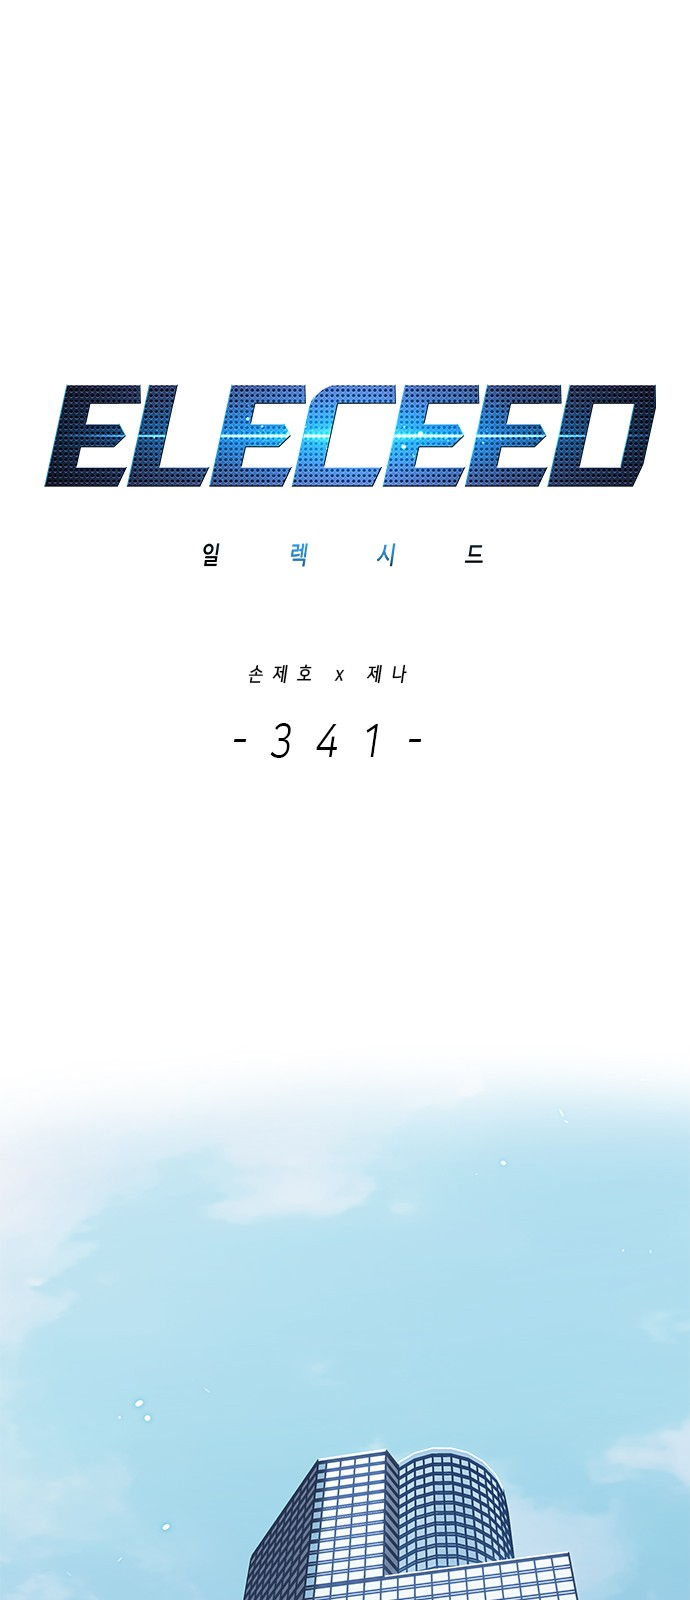

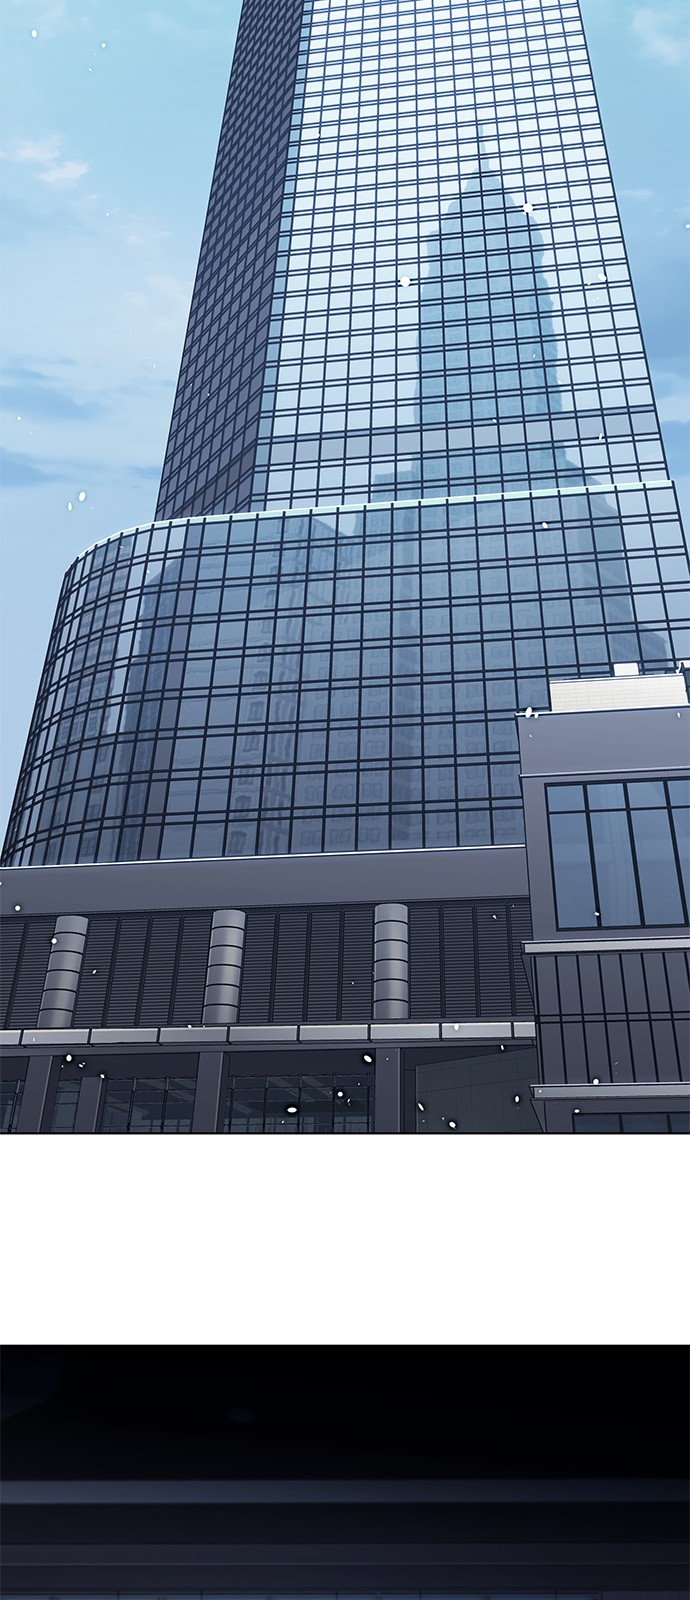

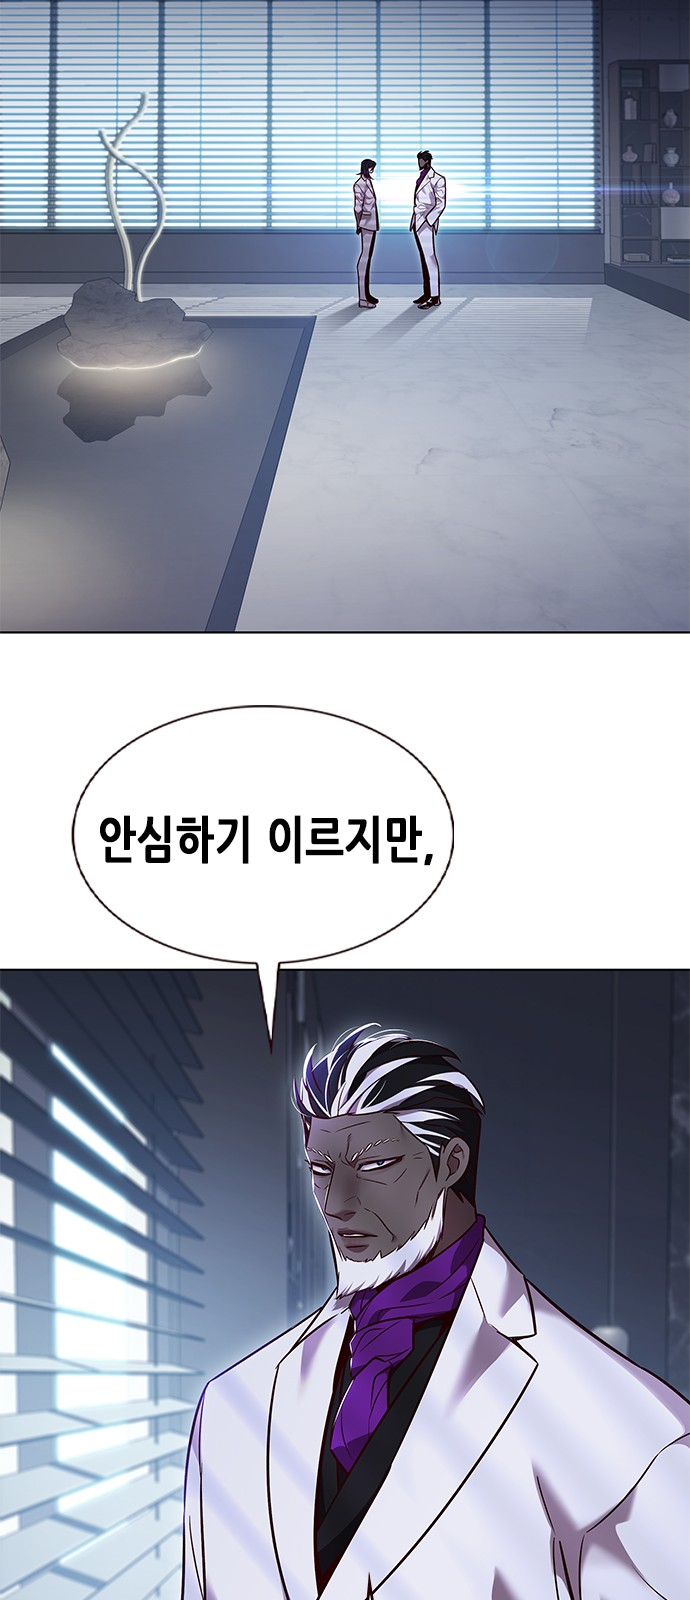

[WindowsPath('img/일렉시드/341/001.jpg'),
 WindowsPath('img/일렉시드/341/002.jpg'),
 WindowsPath('img/일렉시드/341/003.jpg'),
 WindowsPath('img/일렉시드/341/004.jpg'),
 WindowsPath('img/일렉시드/341/005.jpg'),
 WindowsPath('img/일렉시드/341/006.jpg'),
 WindowsPath('img/일렉시드/341/007.jpg'),
 WindowsPath('img/일렉시드/341/008.jpg'),
 WindowsPath('img/일렉시드/341/009.jpg'),
 WindowsPath('img/일렉시드/341/010.jpg'),
 WindowsPath('img/일렉시드/341/011.jpg'),
 WindowsPath('img/일렉시드/341/012.jpg'),
 WindowsPath('img/일렉시드/341/013.jpg'),
 WindowsPath('img/일렉시드/341/014.jpg'),
 WindowsPath('img/일렉시드/341/015.jpg'),
 WindowsPath('img/일렉시드/341/016.jpg'),
 WindowsPath('img/일렉시드/341/017.jpg'),
 WindowsPath('img/일렉시드/341/018.jpg'),
 WindowsPath('img/일렉시드/341/019.jpg'),
 WindowsPath('img/일렉시드/341/020.jpg'),
 WindowsPath('img/일렉시드/341/021.jpg'),
 WindowsPath('img/일렉시드/341/022.jpg'),
 WindowsPath('img/일렉시드/341/023.jpg'),
 WindowsPath('img/일렉시드/341/024.jpg'),
 WindowsPath('img/일렉시드/341/025.jpg'),
 WindowsPath('img/일렉시드/341/026.jpg'),
 WindowsPath

In [12]:
# 2-2. 하나의 네이버 웹툰과 1개의 회차에 대한 Image 다운로드 하기
import re
import requests
from pathlib import Path
from urllib.parse import urljoin, urlparse
from bs4 import BeautifulSoup
from IPython.display import Image, display


def clean_dir_name(value):
    return re.sub(r'[\\/:*?"<>|]', '_', str(value)).strip()


def download_one_episode(title, no, url):
    title_dir = clean_dir_name(title)
    save_dir = Path('img') / title_dir / str(no)
    save_dir.mkdir(parents=True, exist_ok=True)

    headers = {
        'User-Agent': (
            'Mozilla/5.0 (Windows NT 10.0; Win64; x64) '
            'AppleWebKit/537.36 (KHTML, like Gecko) '
            'Chrome/126.0 Safari/537.36'
        ),
        'Referer': url,
    }

    response = requests.get(url, headers=headers, timeout=10)
    response.encoding = 'utf-8'
    response.raise_for_status()

    soup = BeautifulSoup(response.text, 'html.parser')
    viewer = (
        soup.select_one('div.wt_viewer')
        or soup.select_one('#comic_view_area')
        or soup.select_one('div.viewer_img')
        or soup
    )

    image_urls = []
    for img_tag in viewer.select('img'):
        src = img_tag.get('data-src') or img_tag.get('src')
        if not src:
            continue

        img_url = urljoin(url, src.strip())

        if 'image-comic.pstatic.net' not in img_url and 'comic.naver.com' not in img_url:
            continue

        if img_url not in image_urls:
            image_urls.append(img_url)

    if not image_urls:
        raise ValueError('다운로드할 웹툰 이미지를 찾지 못했습니다.')

    saved_files = []
    for index, img_url in enumerate(image_urls, start=1):
        extension = Path(urlparse(img_url).path).suffix.lower()
        if extension not in ['.jpg', '.jpeg', '.png', '.gif', '.webp']:
            extension = '.jpg'

        file_path = save_dir / f'{index:03d}{extension}'
        image_response = requests.get(img_url, headers=headers, timeout=10)
        image_response.raise_for_status()

        with open(file_path, 'wb') as file:
            file.write(image_response.content)

        saved_files.append(file_path)
        print(file_path)

    print(f'총 {len(saved_files)}개의 이미지를 {save_dir}에 다운로드했습니다.')

    for file_path in saved_files[:3]:
        display(Image(filename=str(file_path), width=240))

    return saved_files


download_one_episode(
    '일렉시드',
    341,
    'https://comic.naver.com/webtoon/detail?titleId=717481&no=341&week=wed',
)